# HOMEWORK 5

In this homework you are going to implement the **Floyd-Steinberg dithering** algorithm. Dithering, in general, means that we are adding noise to the signal (in our case digital image) in order to perceive it better. In other words, by adding the noise the objective quality will be worse but the subjective quality will be better (i.e. the image will "look" better).

The details of FS dithering can be found in this [wiki](https://en.wikipedia.org/wiki/Floyd%E2%80%93Steinberg_dithering) page. In order to implement the dithering, we will implement the following steps:
* Define colour pallette
* Quantize the image to obtain the baseline and compute the average quantization error
* Implement FS dithering and compute the average quantization error

You will also have to answer the question at the end of this notebook.

Note: In this homework, you will have the chance to earn some extra points. See the "Bonus" section at the end of the notebook. Good luck!

As always, you are encouraged to use your own images :-)

In [2]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

Let's load the image.

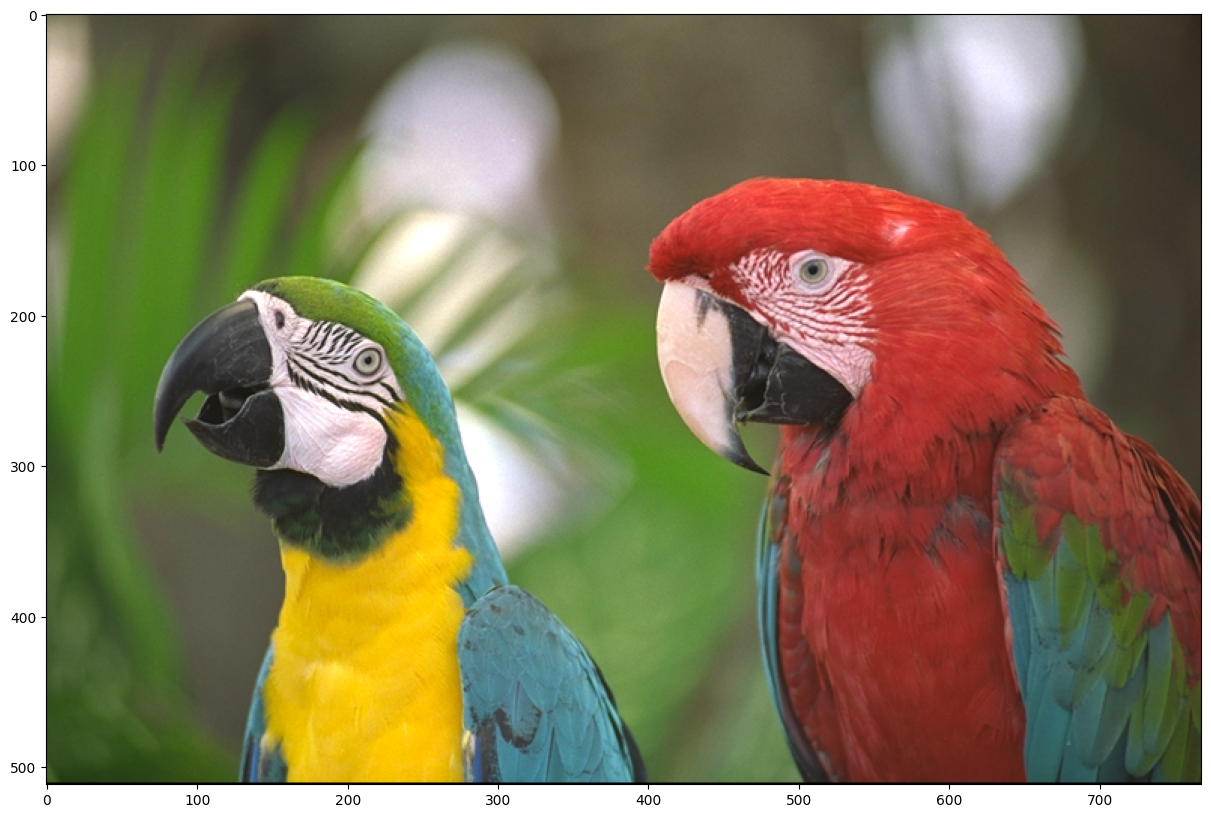

In [3]:
# Load image
img = cv2.imread('../data/kodim23.png')
# Convert it to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# Plot it
plt.imshow(img)

Let's start with gray tones first.

In [4]:
# Black, dark gray, light gray, white
colors = np.array([[0, 0, 0],
                   [64, 64, 64],
                   [192, 192, 192],
                   [255, 255, 255]])

Using the colour pallette, let's quantize the original image.

In [5]:
# Cast the image to float
img = img.astype(np.float32)

# Prepare for quantization
rows, cols, channels = img.shape
quantized = np.zeros_like(img)

# Apply quantization
for r in range(rows):
    for c in range(cols):
        # Extract the original pixel value
        pixel = list(img[r, c, :])
        
        # Find the closest colour from the pallette (using absolute value/Euclidean distance)
        # Note: You may need more than one line of code here
        distances = np.sqrt(np.sum((colors - pixel)**2, axis=1))
        closest_idx = np.argmin(distances)
        new_pixel = colors[closest_idx]
        
        # Apply quantization
        quantized[r, c, :] = new_pixel

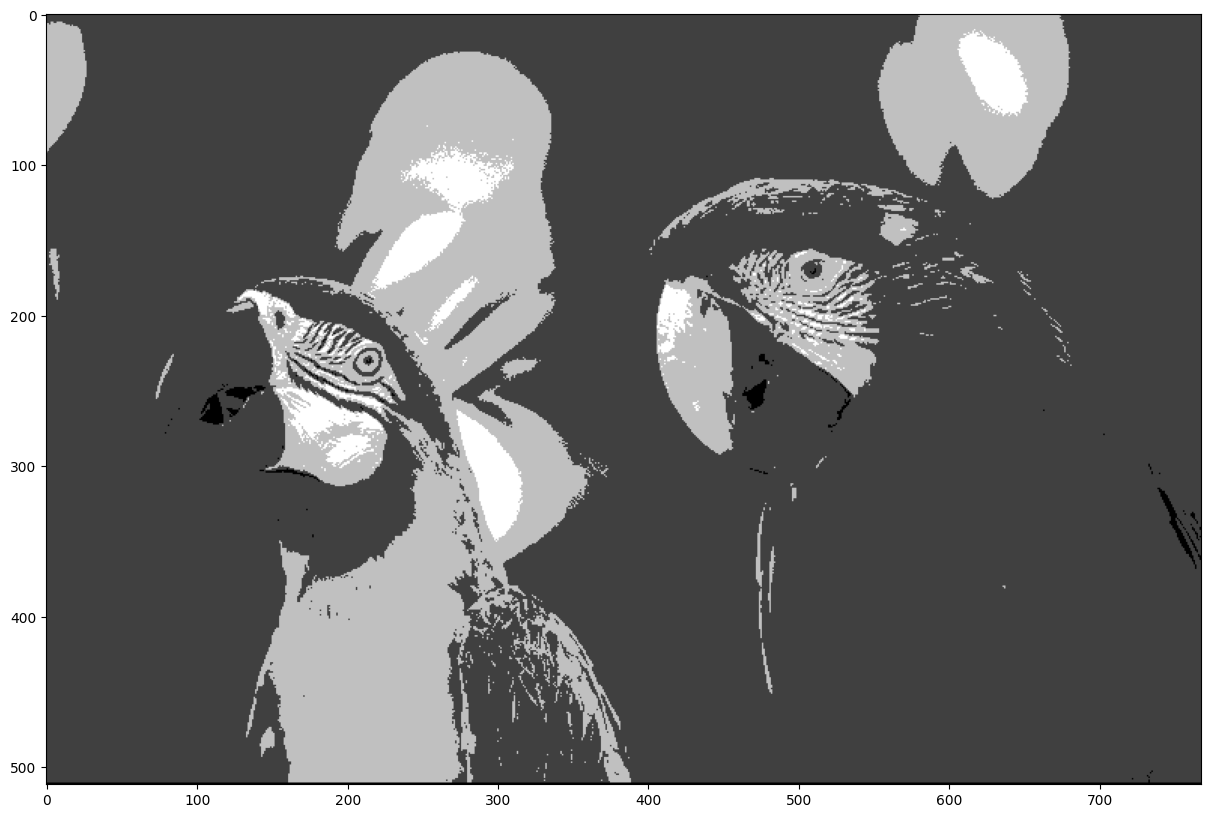

In [6]:
# Show quantized image (don't forget to cast back to uint8)
plt.imshow(quantized.astype(np.uint8))

In [7]:
# Compute average quantization error
avg_quant_error = np.mean(np.abs(img - quantized))
print(avg_quant_error)

32.75775


#### Floyd-Steinberg Dithering
We are now going to implement the FS dithering and compare it to the optimally quantized image we have calculated above.

In [8]:
# Make a temporal copy of the original image, we will need it for error diffusion
img_tmp = np.copy(img)
dithering = np.zeros_like(img)

for r in range(1, rows-1):
    for c in range(1, cols-1):
        # Extract the original pixel value
        pixel = img_tmp[r, c, :]
        # Find the closest colour from the pallette (using absolute value/Euclidean distance)
        # Note: You may need more than one line of code here
        distances = np.sqrt(np.sum((colors - pixel)**2, axis=1))
        closest_idx = np.argmin(distances)
        new_pixel = colors[closest_idx]
        
        # Compute quantization error
        quant_error = pixel - new_pixel
        
        # Diffuse the quantization error accroding to the FS diffusion matrix
        # Note: You may need more than one line of code here
        img_tmp[r, c+1, :] += quant_error * 7/16
        img_tmp[r+1, c-1, :] += quant_error * 3/16
        img_tmp[r+1, c, :] += quant_error * 5/16
        img_tmp[r+1, c+1, :] += quant_error * 1/16
        
        # Apply dithering
        dithering[r, c, :] = new_pixel

(<Axes: >, <matplotlib.image.AxesImage at 0x204cf665e50>)

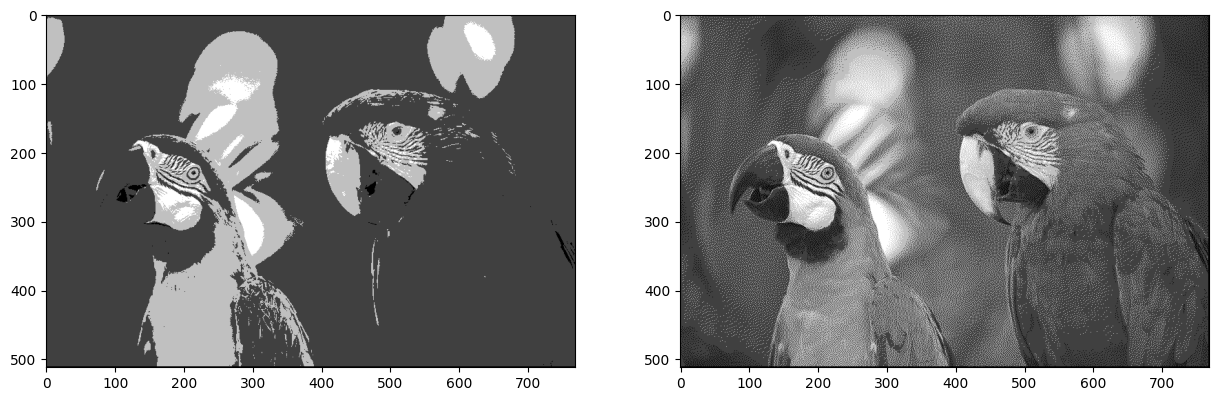

In [9]:
# Show quantized image (don't forget to cast back to uint8)
plt.subplot(121), plt.imshow(quantized.astype(np.uint8))   # optimally quantized
plt.subplot(122), plt.imshow(dithering.astype(np.uint8))   # dithering

In [10]:
# Compute average quantization error for dithered image
avg_dith_error = np.mean(np.abs(img - dithering))
print(avg_dith_error)

41.83168


### Questions
* Which image has higher quantization error? Optimally quantized or dithered?
Dithered has higher error.
* Which image looks better to you?
Dithered looks much better.
* Can you repeat the same process using only two colours: black and white? Show me :-)

82.05588
106.18179


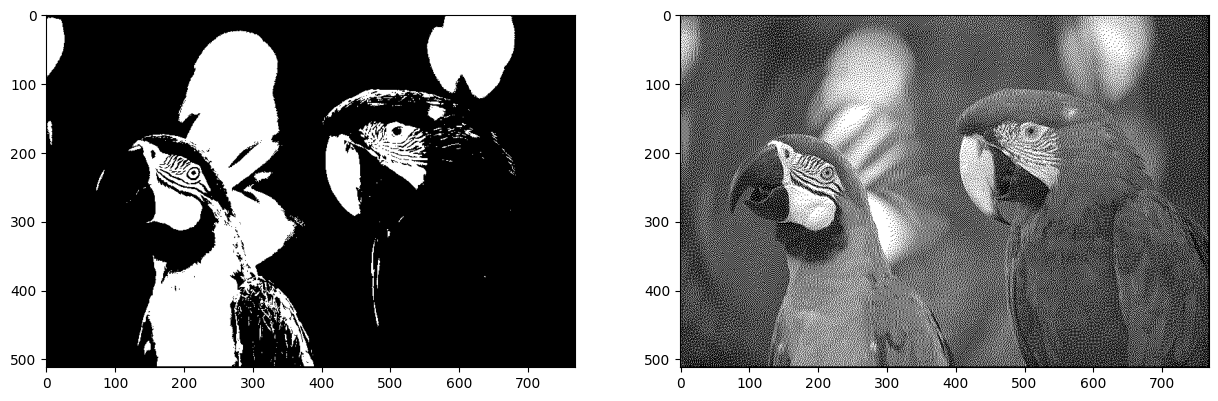

In [11]:
##Black and white variant


# Black white
colors = np.array([[0, 0, 0],
                   [255, 255, 255]])

imgbw =img.astype(np.float32)

# Prepare for quantization
rows, cols, channels = imgbw.shape
quantized = np.zeros_like(imgbw)

# Apply quantization
for r in range(rows):
    for c in range(cols):
        # Extract the original pixel value
        pixel = list(imgbw[r, c, :])
        
        # Find the closest colour from the pallette (using absolute value/Euclidean distance)
        # Note: You may need more than one line of code here
        distances = np.sqrt(np.sum((colors - pixel)**2, axis=1))
        closest_idx = np.argmin(distances)
        new_pixel = colors[closest_idx]
        
        # Apply quantization
        quantized[r, c, :] = new_pixel


# Make a temporal copy of the original image, we will need it for error diffusion
imgbw_tmp = np.copy(img)
dithering = np.zeros_like(img)

for r in range(1, rows-1):
    for c in range(1, cols-1):
        # Extract the original pixel value
        pixel = imgbw_tmp[r, c, :]
        # Find the closest colour from the pallette (using absolute value/Euclidean distance)
        # Note: You may need more than one line of code here
        distances = np.sqrt(np.sum((colors - pixel)**2, axis=1))
        closest_idx = np.argmin(distances)
        new_pixel = colors[closest_idx]
        
        # Compute quantization error
        quant_error = pixel - new_pixel
        
        # Diffuse the quantization error accroding to the FS diffusion matrix
        # Note: You may need more than one line of code here
        imgbw_tmp[r, c+1, :] += quant_error * 7/16
        imgbw_tmp[r+1, c-1, :] += quant_error * 3/16
        imgbw_tmp[r+1, c, :] += quant_error * 5/16
        imgbw_tmp[r+1, c+1, :] += quant_error * 1/16
        
        # Apply dithering
        dithering[r, c, :] = new_pixel


plt.subplot(121), plt.imshow(quantized.astype(np.uint8))   # optimally quantized
plt.subplot(122), plt.imshow(dithering.astype(np.uint8))   # dithering

avg_quant_error = np.mean(np.abs(img - quantized))
print(avg_quant_error)

avg_dith_error = np.mean(np.abs(img - dithering))
print(avg_dith_error)

### Bonus Points

Repeat the homework using a diffrerent image pallette. For instance, you can use an optimal colour
pallette that we can calculate via k-means algorithm. The following snippet of code will give you the 16
optimal colours for your original image.

In [12]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=16).fit(np.reshape(img, (-1, 3)))
colors = kmeans.cluster_centers_

In [ ]:
# Apply FS dithering with K-means generated 16-color palette
print("Using 16 colors from K-means clustering:")
print("Color palette shape:", colors.shape)
print("First few colors:", colors[:5])

# Make a copy of the original image for error diffusion
img_kmeans = img.astype(np.float32)
img_kmeans_tmp = np.copy(img_kmeans)
dithering_kmeans = np.zeros_like(img_kmeans)

# Apply Floyd-Steinberg dithering with K-means colors
for r in range(1, rows-1):
    for c in range(1, cols-1):
        # Extract the original pixel value
        pixel = img_kmeans_tmp[r, c, :]
        
        # Find the closest colour from the K-means palette
        distances = np.sqrt(np.sum((colors - pixel)**2, axis=1))
        closest_idx = np.argmin(distances)
        new_pixel = colors[closest_idx]
        
        # Compute quantization error
        quant_error = pixel - new_pixel
        
        # Diffuse the quantization error according to the FS diffusion matrix
        img_kmeans_tmp[r, c+1, :] += quant_error * 7/16
        img_kmeans_tmp[r+1, c-1, :] += quant_error * 3/16
        img_kmeans_tmp[r+1, c, :] += quant_error * 5/16
        img_kmeans_tmp[r+1, c+1, :] += quant_error * 1/16
        
        # Apply dithering
        dithering_kmeans[r, c, :] = new_pixel

# Display results
plt.figure(figsize=(15, 5))
plt.subplot(131), plt.imshow(img.astype(np.uint8)), plt.title('Original Image')
plt.subplot(132), plt.imshow(dithering_kmeans.astype(np.uint8)), plt.title('FS Dithering with 16 K-means colors')
plt.subplot(133), plt.imshow(dithering.astype(np.uint8)), plt.title('FS Dithering with 4 grayscale colors')

# Compute average quantization error
avg_dith_kmeans_error = np.mean(np.abs(img - dithering_kmeans))
print(f"\nAverage quantization error with 16 K-means colors: {avg_dith_kmeans_error:.2f}")
print(f"Average quantization error with 4 grayscale colors: {avg_dith_error:.2f}")


In [ ]:
# Now let's try with 32 colors
print("="*50)
print("Testing with 32 colors:")
kmeans_32 = KMeans(n_clusters=32).fit(np.reshape(img, (-1, 3)))
colors_32 = kmeans_32.cluster_centers_

# Apply FS dithering with 32 colors
img_32 = img.astype(np.float32)
img_32_tmp = np.copy(img_32)
dithering_32 = np.zeros_like(img_32)

for r in range(1, rows-1):
    for c in range(1, cols-1):
        pixel = img_32_tmp[r, c, :]
        distances = np.sqrt(np.sum((colors_32 - pixel)**2, axis=1))
        closest_idx = np.argmin(distances)
        new_pixel = colors_32[closest_idx]
        
        quant_error = pixel - new_pixel
        img_32_tmp[r, c+1, :] += quant_error * 7/16
        img_32_tmp[r+1, c-1, :] += quant_error * 3/16
        img_32_tmp[r+1, c, :] += quant_error * 5/16
        img_32_tmp[r+1, c+1, :] += quant_error * 1/16
        
        dithering_32[r, c, :] = new_pixel

avg_dith_32_error = np.mean(np.abs(img - dithering_32))
print(f"Average quantization error with 32 colors: {avg_dith_32_error:.2f}")


In [ ]:
# Now let's try with 256 colors
print("="*50)
print("Testing with 256 colors:")
kmeans_256 = KMeans(n_clusters=256).fit(np.reshape(img, (-1, 3)))
colors_256 = kmeans_256.cluster_centers_

# Apply FS dithering with 256 colors
img_256 = img.astype(np.float32)
img_256_tmp = np.copy(img_256)
dithering_256 = np.zeros_like(img_256)

for r in range(1, rows-1):
    for c in range(1, cols-1):
        pixel = img_256_tmp[r, c, :]
        distances = np.sqrt(np.sum((colors_256 - pixel)**2, axis=1))
        closest_idx = np.argmin(distances)
        new_pixel = colors_256[closest_idx]
        
        quant_error = pixel - new_pixel
        img_256_tmp[r, c+1, :] += quant_error * 7/16
        img_256_tmp[r+1, c-1, :] += quant_error * 3/16
        img_256_tmp[r+1, c, :] += quant_error * 5/16
        img_256_tmp[r+1, c+1, :] += quant_error * 1/16
        
        dithering_256[r, c, :] = new_pixel

avg_dith_256_error = np.mean(np.abs(img - dithering_256))
print(f"Average quantization error with 256 colors: {avg_dith_256_error:.2f}")


In [ ]:
# Display all results for comparison
plt.figure(figsize=(20, 10))

plt.subplot(2, 3, 1), plt.imshow(img.astype(np.uint8)), plt.title('Original Image')
plt.subplot(2, 3, 2), plt.imshow(dithering_kmeans.astype(np.uint8)), plt.title('FS Dithering - 16 K-means colors')
plt.subplot(2, 3, 3), plt.imshow(dithering_32.astype(np.uint8)), plt.title('FS Dithering - 32 K-means colors')
plt.subplot(2, 3, 4), plt.imshow(dithering_256.astype(np.uint8)), plt.title('FS Dithering - 256 K-means colors')
plt.subplot(2, 3, 5), plt.imshow(dithering.astype(np.uint8)), plt.title('FS Dithering - 4 grayscale colors')
plt.subplot(2, 3, 6), plt.imshow(quantized.astype(np.uint8)), plt.title('Simple Quantization - 4 grayscale colors')

plt.tight_layout()
plt.show()

# Summary of results
print("\n" + "="*60)
print("SUMMARY OF QUANTIZATION ERRORS:")
print("="*60)
print(f"Simple quantization (4 grayscale):     {avg_quant_error:.2f}")
print(f"FS dithering (4 grayscale):            {avg_dith_error:.2f}")
print(f"FS dithering (16 K-means colors):      {avg_dith_kmeans_error:.2f}")
print(f"FS dithering (32 K-means colors):      {avg_dith_32_error:.2f}")
print(f"FS dithering (256 K-means colors):     {avg_dith_256_error:.2f}")
print("="*60)


Apply FS dithering the same way you did before.
* How does the result look like to you?
* What happens if we use 32 colours?
* And what happens if we use 256 colours?